# 1.4 Runtime analysis

1.4 Runtime analysis: two log-log sweeps with fitted slopes (runtime vs k
at N=512, runtime vs N at k=15), im2col peak-memory table, and the separable
speedup measurement at 512^2 and 2048^2 needed for the written discussion.
All timings use the separable Gaussian kernel (rank 1 at every k), matching
the kernel used for the 1.1 correctness table.

In [2]:
import sys
import time
from pathlib import Path

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
sys.path.insert(0, str(Path.cwd()))
from starter import (kernel_bank, conv2d_taps, conv2d_im2col, conv2d_fft,
                      conv2d_separable)

In [5]:
ROOT = Path.cwd().parents[1]

full = np.asarray(Image.open(ROOT / "images/p1/base_2048.png")).astype(float)


def time_fn(fn, img, K, reps=7):
    """Median of `reps` timings. Median (not best-of-N) is used because
    best-of-N timings at small k/N are dominated by occasional very fast
    outlier runs (OS/GC noise), which distorts the fitted log-log slope;
    the median is the standard robust choice for wall-clock microbenchmarks."""
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        fn(img, K)
        t1 = time.perf_counter()
        ts.append(t1 - t0)
    ts.sort()
    return ts[len(ts) // 2]

In [6]:
def fit_loglog_slope(xs, ys):
    """Least-squares slope of log(y) vs log(x)."""
    lx, ly = np.log(xs), np.log(ys)
    slope, intercept = np.polyfit(lx, ly, 1)
    return slope, intercept

In [7]:
# Sweep 1: runtime vs k, N=512 fixed

In [8]:
N_FIXED = 512
K_VALUES = [3, 7, 11, 15, 21, 31]
crop512 = full[:N_FIXED, :N_FIXED]

In [9]:
print(f"=== Sweep 1: runtime vs k, N={N_FIXED} ===")
times_taps_k, times_im2col_k, times_fft_k = [], [], []
for k in K_VALUES:
    K = kernel_bank(k)["gaussian"]
    t_taps = time_fn(conv2d_taps, crop512, K)
    t_im2col = time_fn(conv2d_im2col, crop512, K)
    t_fft = time_fn(conv2d_fft, crop512, K)
    times_taps_k.append(t_taps)
    times_im2col_k.append(t_im2col)
    times_fft_k.append(t_fft)
    print(f"k={k:3d}  taps={t_taps:8.4f}s  im2col={t_im2col:8.4f}s  fft={t_fft:8.4f}s")

=== Sweep 1: runtime vs k, N=512 ===


k=  3  taps=  0.0053s  im2col=  0.0147s  fft=  0.0922s


k=  7  taps=  0.0303s  im2col=  0.0619s  fft=  0.0220s


k= 11  taps=  0.0832s  im2col=  0.1478s  fft=  0.0209s


k= 15  taps=  0.1331s  im2col=  0.3452s  fft=  0.1530s


k= 21  taps=  0.4716s  im2col=  0.7377s  fft=  0.0247s


k= 31  taps=  1.0187s  im2col=  1.5071s  fft=  0.1761s


In [10]:
slope_taps_k, _ = fit_loglog_slope(K_VALUES, times_taps_k)
slope_im2col_k, _ = fit_loglog_slope(K_VALUES, times_im2col_k)
print(f"fitted slope (taps) vs k: {slope_taps_k:.3f}  (theory: 2.0)")
print(f"fitted slope (im2col) vs k: {slope_im2col_k:.3f}")

fitted slope (taps) vs k: 2.263  (theory: 2.0)
fitted slope (im2col) vs k: 2.028


In [11]:
# Sweep 2: runtime vs N, k=15 fixed

In [12]:
K_FIXED = 15
N_VALUES = [128, 256, 512, 1024, 2048]
Kgauss15 = kernel_bank(K_FIXED)["gaussian"]

In [13]:
print(f"\n=== Sweep 2: runtime vs N, k={K_FIXED} ===")
times_taps_N, times_im2col_N, times_fft_N = [], [], []
peak_mem_N = []
for N in N_VALUES:
    # Fewer reps for large N: absolute times are already large (seconds),
    # so relative timing noise matters less and 7 reps would be very slow.
    reps = 7 if N <= 512 else 3
    crop = full[:N, :N]
    t_taps = time_fn(conv2d_taps, crop, Kgauss15, reps=reps)
    t_im2col = time_fn(conv2d_im2col, crop, Kgauss15, reps=reps)
    t_fft = time_fn(conv2d_fft, crop, Kgauss15, reps=reps)
    times_taps_N.append(t_taps)
    times_im2col_N.append(t_im2col)
    times_fft_N.append(t_fft)
    # peak im2col patch-matrix memory: (N*N, k*k) float64 array
    peak_bytes = N * N * K_FIXED * K_FIXED * 8
    peak_mem_N.append(peak_bytes)
    print(f"N={N:5d}  taps={t_taps:9.4f}s  im2col={t_im2col:9.4f}s  fft={t_fft:9.4f}s  "
          f"im2col_mem={peak_bytes/1e6:9.1f}MB")


=== Sweep 2: runtime vs N, k=15 ===


N=  128  taps=   0.0101s  im2col=   0.0214s  fft=   0.0053s  im2col_mem=     29.5MB


N=  256  taps=   0.0415s  im2col=   0.0988s  fft=   0.0068s  im2col_mem=    118.0MB


N=  512  taps=   0.2369s  im2col=   0.3642s  fft=   0.1437s  im2col_mem=    471.9MB


N= 1024  taps=   0.9886s  im2col=   1.0654s  fft=   0.2568s  im2col_mem=   1887.4MB


N= 2048  taps=   5.6884s  im2col=  11.6783s  fft=   1.2461s  im2col_mem=   7549.7MB


In [14]:
slope_taps_N, _ = fit_loglog_slope(N_VALUES, times_taps_N)
slope_im2col_N, _ = fit_loglog_slope(N_VALUES, times_im2col_N)
print(f"fitted slope (taps) vs N: {slope_taps_N:.3f}  (theory: 2.0, since H*W ~ N^2)")
print(f"fitted slope (im2col) vs N: {slope_im2col_N:.3f}")

fitted slope (taps) vs N: 2.285  (theory: 2.0, since H*W ~ N^2)
fitted slope (im2col) vs N: 2.162


In [15]:
# Part (c): separable speedup at 512^2 and 2048^2, k=15

In [16]:
print(f"\n=== Separable speedup, k={K_FIXED} ===")
speedups = {}
for N in (512, 2048):
    crop = full[:N, :N]
    t_taps = time_fn(conv2d_taps, crop, Kgauss15, reps=3)
    t_sep = time_fn(conv2d_separable, crop, Kgauss15, reps=3)
    speedup = t_taps / t_sep
    speedups[N] = (t_taps, t_sep, speedup)
    print(f"N={N:5d}  taps={t_taps:8.4f}s  separable={t_sep:8.4f}s  "
          f"speedup={speedup:.2f}x  (theory: k/2={K_FIXED/2:.1f}x)")


=== Separable speedup, k=15 ===


N=  512  taps=  0.2611s  separable=  0.0285s  speedup=9.15x  (theory: k/2=7.5x)


N= 2048  taps=  4.7191s  separable=  0.7227s  speedup=6.53x  (theory: k/2=7.5x)


In [17]:
# Plots

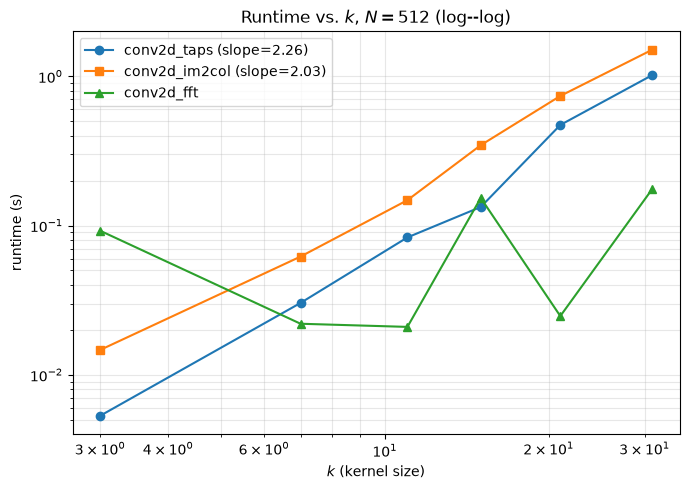

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(K_VALUES, times_taps_k, "o-", label=f"conv2d_taps (slope={slope_taps_k:.2f})")
ax.loglog(K_VALUES, times_im2col_k, "s-", label=f"conv2d_im2col (slope={slope_im2col_k:.2f})")
ax.loglog(K_VALUES, times_fft_k, "^-", label="conv2d_fft")
ax.set_xlabel("$k$ (kernel size)")
ax.set_ylabel("runtime (s)")
ax.set_title(f"Runtime vs. $k$, $N={N_FIXED}$ (log--log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

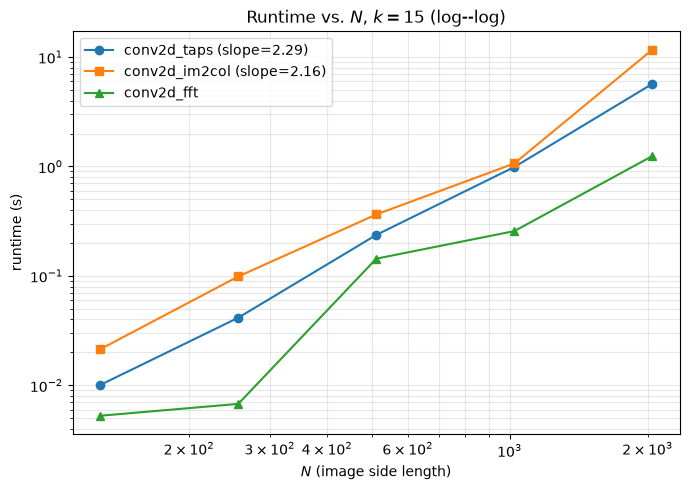

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(N_VALUES, times_taps_N, "o-", label=f"conv2d_taps (slope={slope_taps_N:.2f})")
ax.loglog(N_VALUES, times_im2col_N, "s-", label=f"conv2d_im2col (slope={slope_im2col_N:.2f})")
ax.loglog(N_VALUES, times_fft_N, "^-", label="conv2d_fft")
ax.set_xlabel("$N$ (image side length)")
ax.set_ylabel("runtime (s)")
ax.set_title(f"Runtime vs. $N$, $k={K_FIXED}$ (log--log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

In [20]:
# Tables

In [21]:
print(f"\n{'N':>6s} {'patch matrix shape':>22s} {'peak memory':>14s} {'x image size':>14s}")
for N, mem in zip(N_VALUES, peak_mem_N):
    img_bytes = N * N * 8
    print(f"{N:6d} {'(' + str(N*N) + ', ' + str(K_FIXED*K_FIXED) + ')':>22s} "
          f"{mem/1e6:10.1f} MB {mem/img_bytes:10.0f}x")


     N     patch matrix shape    peak memory   x image size
   128           (16384, 225)       29.5 MB        225x
   256           (65536, 225)      118.0 MB        225x
   512          (262144, 225)      471.9 MB        225x
  1024         (1048576, 225)     1887.4 MB        225x
  2048         (4194304, 225)     7549.7 MB        225x


In [22]:
print(f"\n{'N':>6s} {'conv2d_taps':>14s} {'conv2d_separable':>18s} {'speedup':>10s} "
      f"(theory: k/2={K_FIXED/2:.1f}x)")
for N in (512, 2048):
    t_taps, t_sep, speedup = speedups[N]
    print(f"{N:6d} {t_taps:13.4f}s {t_sep:17.4f}s {speedup:9.2f}x")


     N    conv2d_taps   conv2d_separable    speedup (theory: k/2=7.5x)
   512        0.2611s            0.0285s      9.15x
  2048        4.7191s            0.7227s      6.53x
